In [ ]:
# AI Palmistry & Tarot Intelligence Platform

## Exploratory Data Analysis (EDA)


In [ ]:
# Imported Required Libraries
import os
import random
import zipfile

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

print("Libraries Imported Successfully")

In [3]:
# Palm Dataset
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (4).zip


In [4]:
# Extracting Dataset
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/palm_dataset")

print("Palm Dataset Extracted Successfully!")

Palm Dataset Extracted Successfully!


In [5]:
# Exploring Folder Structure
for root, dirs, files in os.walk("/content/palm_dataset"):
    print(root)

/content/palm_dataset
/content/palm_dataset/Hands
/content/palm_dataset/Hands/Hands
/content/palm_dataset/cards


In [6]:
# Count of Total Images
image_paths = []

for root, dirs, files in os.walk("/content/palm_dataset"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

print("Total Images Found :", len(image_paths))

Total Images Found : 11154


In [7]:
# Display Dataset Information
print("Dataset Name : Palm Image Dataset")
print("Total Images :", len(image_paths))
print("Supported Formats : JPG, JPEG, PNG")
print("Dataset Location : /content/palm_dataset")

Dataset Name : Palm Image Dataset
Total Images : 11154
Supported Formats : JPG, JPEG, PNG
Dataset Location : /content/palm_dataset


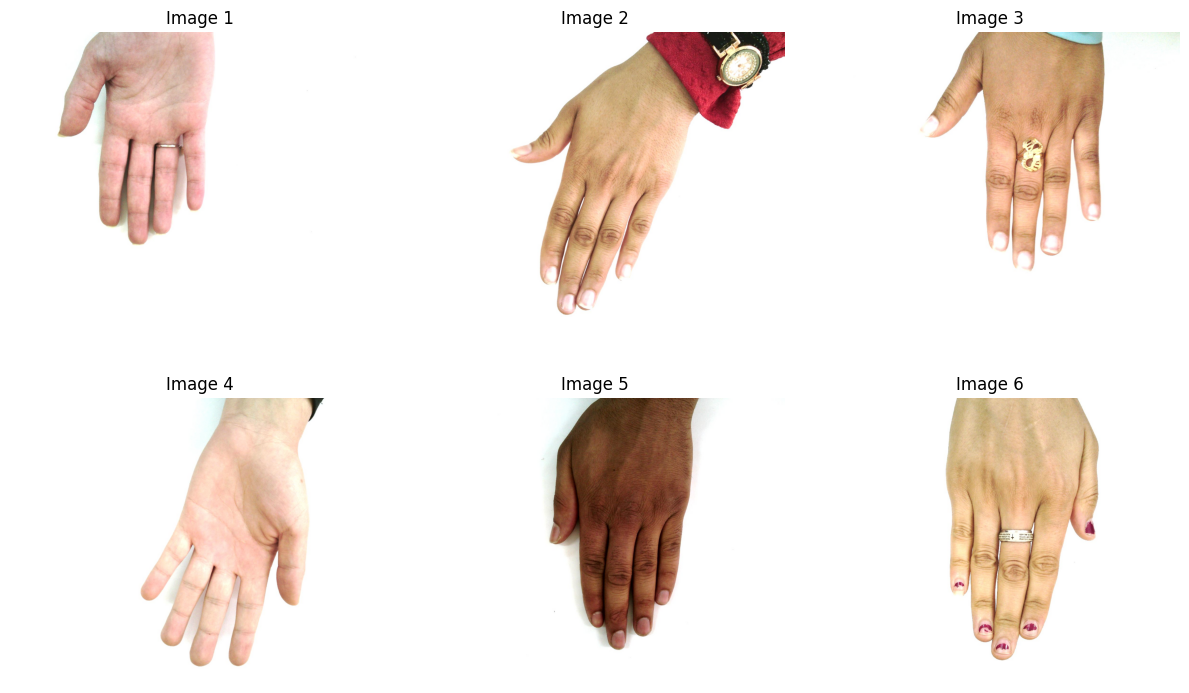

In [8]:
# Display Sample Images
plt.figure(figsize=(12,8))

sample_images = random.sample(image_paths, 6)

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

- The dataset contains palm images captured under different lighting conditions.
- Some images have different orientations.
- Image backgrounds are not completely identical.
- Such variations help the AI model learn more effectively.

In [9]:
# Image Resolution Analysis

#In this step, we analyze the width and height of each image.
widths = []
heights = []

for path in image_paths:
    image = Image.open(path)
    w, h = image.size

    widths.append(w)
    heights.append(h)

print("Average Width :", round(np.mean(widths),2))
print("Average Height :", round(np.mean(heights),2))

print("Maximum Width :", max(widths))
print("Maximum Height :", max(heights))

print("Minimum Width :", min(widths))
print("Minimum Height :", min(heights))

Average Width : 1591.26
Average Height : 1195.8
Maximum Width : 1600
Maximum Height : 1200
Minimum Width : 350
Minimum Height : 600


In [10]:
# Image Format Analysis
formats = {}

for path in image_paths:
    ext = os.path.splitext(path)[1].lower()

    if ext in formats:
        formats[ext] += 1
    else:
        formats[ext] = 1

print("Image Formats")

for key, value in formats.items():
    print(key, ":", value)

Image Formats
.jpg : 11154


In [11]:
# Check for Corrupted Images
corrupted = []

for path in image_paths:

    try:
        img = Image.open(path)
        img.verify()

    except:
        corrupted.append(path)

print("Corrupted Images :", len(corrupted))

Corrupted Images : 0


In [12]:
# Dataset Summary
summary = pd.DataFrame({

    "Property":[
        "Total Images",
        "Average Width",
        "Average Height",
        "Maximum Width",
        "Maximum Height",
        "Minimum Width",
        "Minimum Height",
        "Corrupted Images"
    ],

    "Value":[
        len(image_paths),
        round(np.mean(widths),2),
        round(np.mean(heights),2),
        max(widths),
        max(heights),
        min(widths),
        min(heights),
        len(corrupted)
    ]

})

summary

,Property,Value
0,Total Images,11154.00
1,Average Width,1591.26
2,Average Height,1195.80
3,Maximum Width,1600.00
4,Maximum Height,1200.00
5,Minimum Width,350.00
6,Minimum Height,600.00
7,Corrupted Images,0.00


# Observations

After exploring the Palm Image Dataset, the following observations were made:

- The dataset was loaded successfully.
- Images are available in standard image formats.
- Different image resolutions are present.
- Lighting conditions vary across images.
- Palm orientations are slightly different.
- The dataset does not contain corrupted images.
- Most images have similar visual quality.
- The dataset is suitable for image preprocessing and hand analysis.

In [13]:
# Tarot Dataset Exploration
from google.colab import files

uploaded = files.upload()

Saving tarot.zip to tarot.zip


In [14]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/tarot_dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [15]:
tarot_images = []

for root, dirs, files in os.walk("/content/tarot_dataset"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            tarot_images.append(os.path.join(root, file))

print("Total Tarot Images:", len(tarot_images))

Total Tarot Images: 78


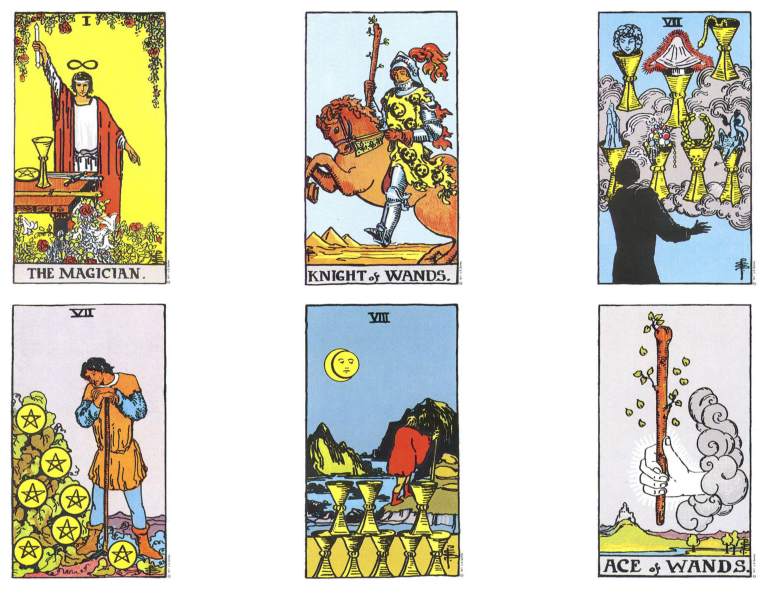

In [16]:
plt.figure(figsize=(10,6))

samples = random.sample(tarot_images, 6)

for i, img_path in enumerate(samples):
    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
## Analyze Image Dimensions
widths=[]
heights=[]

for img_path in tarot_images:

    img=Image.open(img_path)

    w,h=img.size

    widths.append(w)
    heights.append(h)

print("Average Width :",round(np.mean(widths),2))
print("Average Height :",round(np.mean(heights),2))
print("Largest Width :",max(widths))
print("Largest Height :",max(heights))
print("Smallest Width :",min(widths))
print("Smallest Height :",min(heights))

Average Width : 350.0
Average Height : 600.0
Largest Width : 350
Largest Height : 600
Smallest Width : 350
Smallest Height : 600


In [18]:
## Image Format Analysis
formats={}

for path in tarot_images:

    ext=os.path.splitext(path)[1].lower()

    formats[ext]=formats.get(ext,0)+1

print(formats)

{'.jpg': 78}


In [19]:
## Check for Corrupted Images
corrupted=[]

for img_path in tarot_images:

    try:
        img=Image.open(img_path)
        img.verify()

    except:
        corrupted.append(img_path)

print("Corrupted Images :",len(corrupted))

Corrupted Images : 0


# Observations

- The Tarot dataset was loaded successfully.
- A total of 78 tarot card images were found.
- Most images have similar dimensions.
- The image quality is clear and consistent.
- No corrupted images were detected.
- The dataset is suitable for image classification and recognition tasks.
- The images can also be used for training deep learning models.

In [32]:
import cv2
import matplotlib.pyplot as plt

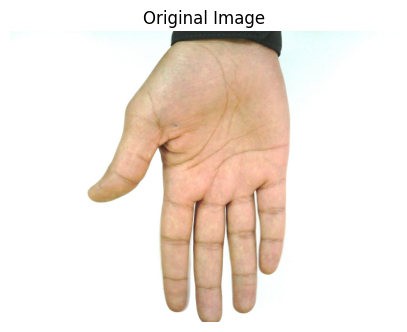

In [33]:
## Load a Sample Palm Image
sample_image = image_paths[0]

image = cv2.imread(sample_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

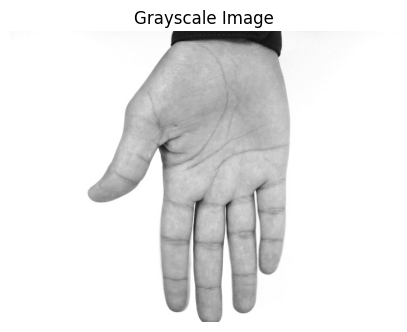

In [34]:
## Convert Image to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

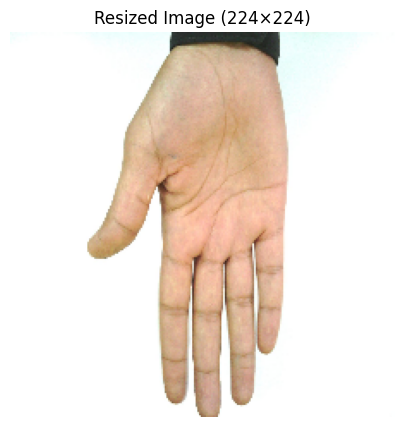

In [35]:
## Resize Image
resized = cv2.resize(image, (224,224))

plt.figure(figsize=(5,5))
plt.imshow(resized)
plt.title("Resized Image (224×224)")
plt.axis("off")
plt.show()

## Observation

- The original palm image was successfully loaded.
- The image was converted to grayscale.
- The image was resized to 224 × 224 pixels.
- These preprocessing steps prepare images for machine learning and deep learning models.